# 2D infinite plate with hole: linear elasticity

This notebook reproduces the deterministic linear-elastic quarter-plate benchmark from the MATLAB 2D example. It uses the vendored `Mesh_infPlate.m` mesh and solves the plane-strain problem with symmetry constraints on the left and bottom edges and traction on the right edge.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np

from statFEMx.config import InfinitePlate2DConfig
from statFEMx.fem.infinite_plate_2d import solve_infinite_plate_linear_2d


In [2]:
youngs_modulus = 200.0
poisson_ratio = 0.25
traction = 100.0
output_path = Path("results_notebook/infinite_plate_2d_linear.ipynb.npz")

cfg = InfinitePlate2DConfig(
    youngs_modulus=youngs_modulus,
    poisson_ratio=poisson_ratio,
    traction=traction,
)


In [3]:
solution = solve_infinite_plate_linear_2d(cfg)

output_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    output_path,
    node_coordinates=solution.node_coordinates,
    element_nodes=solution.element_nodes,
    displacement=solution.displacement,
    ux=solution.ux,
    uy=solution.uy,
    force=solution.force,
    reactions=solution.reactions,
    von_mises=solution.von_mises,
)

print(f"saved {output_path}")
print(f"max |ux| = {np.max(np.abs(solution.ux)):.6e}")
print(f"max |uy| = {np.max(np.abs(solution.uy)):.6e}")
print(f"max von Mises = {np.max(solution.von_mises):.6e}")


saved results_notebook/infinite_plate_2d_linear.ipynb.npz
max |ux| = 5.048210e+02
max |uy| = 7.705201e+01
max von Mises = 2.668782e+02


In [4]:
coords = solution.node_coordinates
quads = solution.element_nodes
triangles = np.vstack([
    quads[:, [0, 1, 2]],
    quads[:, [0, 2, 3]],
])
triangulation = mtri.Triangulation(coords[:, 0], coords[:, 1], triangles)


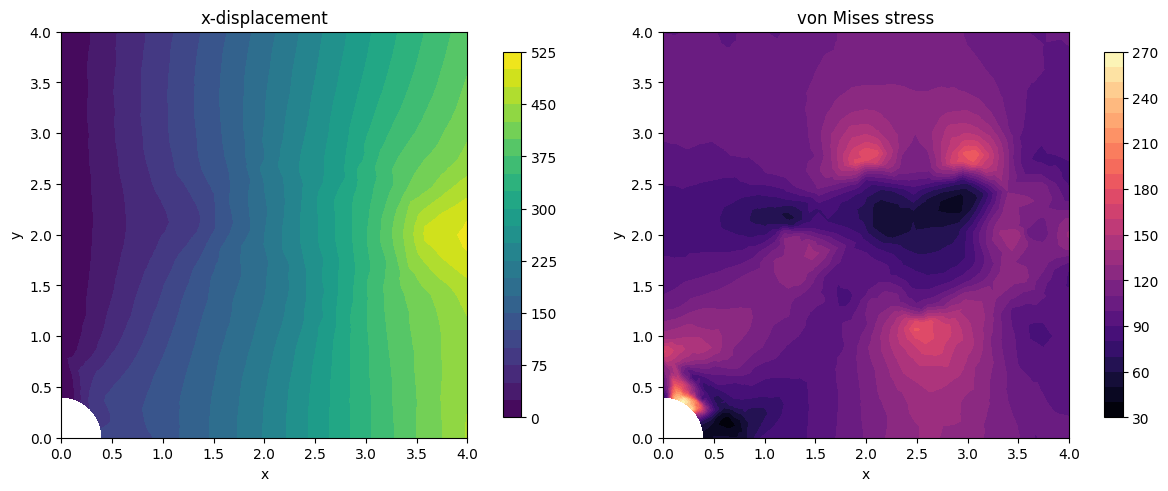

In [5]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

t1 = axes[0].tricontourf(triangulation, solution.ux, levels=24, cmap="viridis")
axes[0].set_title("x-displacement")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(t1, ax=axes[0], shrink=0.9)

t2 = axes[1].tricontourf(triangulation, solution.von_mises, levels=24, cmap="magma")
axes[1].set_title("von Mises stress")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
fig.colorbar(t2, ax=axes[1], shrink=0.9)

plt.show()
